In [37]:
import numpy as np

x=np.random.rand(100,1)
y=10+7*x+np.random.randn(100,1)

In [38]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    datasets_path = Path("datasets")
    tarball_path = datasets_path / "housing.tgz"

    datasets_path.mkdir(parents=True, exist_ok=True)

    if not tarball_path.is_file():
        url = "https://raw.githubusercontent.com/ageron/data/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)

    with tarfile.open(tarball_path) as housing_tarball:
        housing_tarball.extractall(path=datasets_path)

    return pd.read_csv(datasets_path / "housing" / "housing.csv")

housing = load_housing_data()
housing.head()

/tmp/ipykernel_6544/88030667.py:17: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path=datasets_path)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


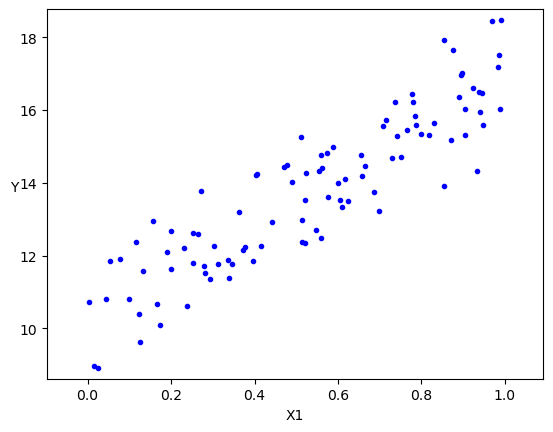

In [39]:
import matplotlib.pyplot as plt

plt.plot(x, y, "b.")
plt.xlabel("X1", fontsize=10)
plt.ylabel("Y", rotation=0, fontsize=10)
plt.axis([x[:].min()-0.1, x[:].max()+0.1, y[:].min()-0.3, y[:].max()+0.3])
plt.show()


In [40]:
x_b=np.c_[np.ones((100,1)), x]
theta_best=np.linalg.inv(x_b.T.dot(x_b)).dot(x_b.T).dot(y)
print("Коэффициент модели линейной регрессии:")
print(theta_best)

Коэффициент модели линейной регрессии:
[[10.17795097]
 [ 6.74185952]]


In [41]:
from sklearn.metrics import mean_squared_error, r2_score
x_new=np.array(([0],[1]))
x_new_b=np.c_[np.ones((2,1)), x_new]
y_predict=x_new_b.dot(theta_best)
print("Значение прогноза линейной регрессии: ")
print(y_predict)
y_target=10+7*x_new
print("Целевые значения:")
print(y_target)

rmse_lr=np.sqrt(mean_squared_error(y_target, y_predict))
r2_lr=r2_score(y_target, y_predict)
print("RMSE for LR", rmse_lr)
print("R2_score for LR", r2_lr)

Значение прогноза линейной регрессии: 
[[10.17795097]
 [16.91981048]]
Целевые значения:
[[10]
 [17]]
RMSE for LR 0.13801613098932067
R2_score for LR 0.998445024292795


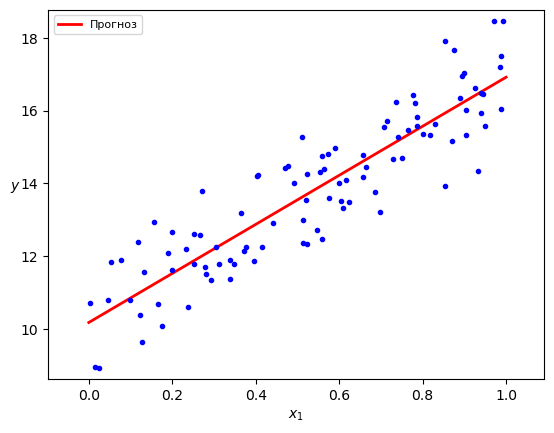

In [42]:
plt.plot(x_new, y_predict, "r-", linewidth=2, label="Прогноз")
plt.plot(x, y, "b.")
plt.xlabel("$x_1$", fontsize=10)
plt.ylabel("$y$", rotation=0, fontsize=10)
plt.legend(loc="upper left", fontsize=8)
plt.axis([x[:].min()-0.1, x[:].max()+0.1, y[:].min()-0.3, y[:].max()+0.3])
plt.show()


In [43]:
from sklearn.linear_model import LinearRegression

lin_reg=LinearRegression()
lin_reg.fit(x,y)
lin_reg.intercept_, lin_reg.coef_

(array([10.17795097]), array([[6.74185952]]))

In [44]:
y_predict=lin_reg.predict(x_new)
print("Целевые значения:")
print(y_target)
rmse_lr=np.sqrt(mean_squared_error(y_target, y_predict))
r2_lr=r2_score(y_target, y_predict)
print("RMSE for LR", rmse_lr)
print("R2_score for LR", r2_lr)

Целевые значения:
[[10]
 [17]]
RMSE for LR 0.138016130989321
R2_score for LR 0.998445024292795


Найденный вектор параметров ЛР:
 [[-9.46140962e+12]
 [-5.42560202e+12]]
Значение прогноза линейной регрессии: 
 [[10.17795097]
 [16.91981048]]
RMSE for LR:  0.138016130989321
R2 score for LR:  0.998445024292795


/tmp/ipykernel_6544/4108807976.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left", fontsize=8)


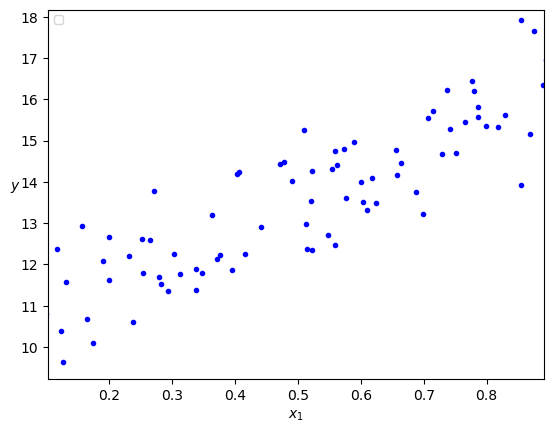

In [45]:
eta=0.775
n_interations=1000
m=100#Dataset size

theta=np.random.rand(2,1)
for interation in range(n_interations):
    gradients=2/m*x_b.T.dot(x_b.dot(theta)-y)
    theta=theta-eta*gradients
    y_predict_gd=x_new_b.dot(theta)

    plt.plot(x_new_b, y_predict_gd, color="green", linestyle=":", linewidth=0.5)
print("Найденный вектор параметров ЛР:\n", theta)

print("Значение прогноза линейной регрессии: \n", y_predict)
rmse_lr=np.sqrt(mean_squared_error(y_target, y_predict))
r2_lr=r2_score(y_target, y_predict)
print("RMSE for LR: ", rmse_lr)
print("R2 score for LR: ", r2_lr)


plt.plot(x_new_b, y_predict_gd, color="red", linestyle="-", linewidth=2)

plt.plot(x, y, "b.", linewidth=0.5)

plt.xlabel("$x_1$", fontsize=10)
plt.ylabel("$y$", rotation=0, fontsize=10)
plt.legend(loc="upper left", fontsize=8)
plt.axis([x[:].min()+0.1, x[:].max()-0.1, y[:].min()+0.3, y[:].max()-0.3])
plt.show()

Найденный вектор параметров ЛР:
 [[10.22092987]
 [ 6.66691096]]
Значение прогноза линейной регрессии: 
 [[10.17795097]
 [16.91981048]]
RMSE for LR:  0.138016130989321
R2 score for LR:  0.998445024292795


/tmp/ipykernel_6544/2067479726.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left", fontsize=8)


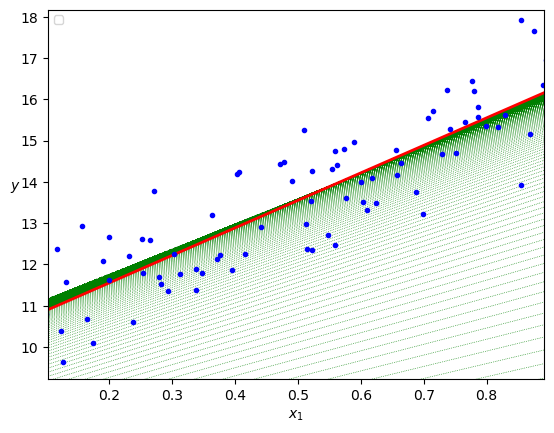

In [46]:
eta=0.02
n_interations=1000
m=100#Dataset size

theta=np.random.rand(2,1)
for interation in range(n_interations):
    gradients=2/m*x_b.T.dot(x_b.dot(theta)-y)
    theta=theta-eta*gradients
    y_predict_gd=x_new_b.dot(theta)

    plt.plot(x_new_b, y_predict_gd, color="green", linestyle=":", linewidth=0.5)
print("Найденный вектор параметров ЛР:\n", theta)

print("Значение прогноза линейной регрессии: \n", y_predict)
rmse_lr=np.sqrt(mean_squared_error(y_target, y_predict))
r2_lr=r2_score(y_target, y_predict)
print("RMSE for LR: ", rmse_lr)
print("R2 score for LR: ", r2_lr)


plt.plot(x_new_b, y_predict_gd, color="red", linestyle="-", linewidth=2)

plt.plot(x, y, "b.", linewidth=0.5)

plt.xlabel("$x_1$", fontsize=10)
plt.ylabel("$y$", rotation=0, fontsize=10)
plt.legend(loc="upper left", fontsize=8)
plt.axis([x[:].min()+0.1, x[:].max()-0.1, y[:].min()+0.3, y[:].max()-0.3])
plt.show()

Найденный вектор параметров ЛР:
 [[10.17795097]
 [ 6.74185952]]
Значение прогноза линейной регрессии: 
 [[10.17795097]
 [16.91981048]]
RMSE for LR:  0.138016130989321
R2 score for LR:  0.998445024292795


/tmp/ipykernel_6544/1283859730.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left", fontsize=8)


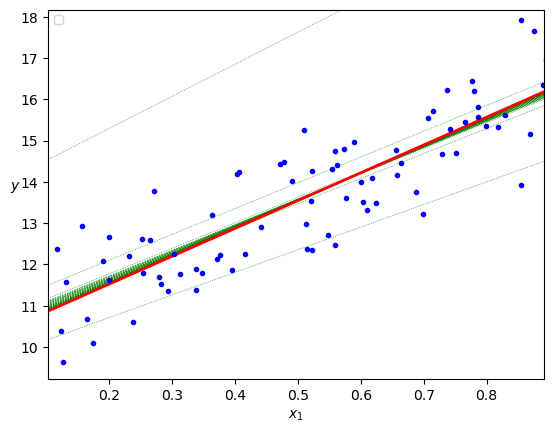

In [47]:
eta=0.5
n_interations=1000
m=100#Dataset size

theta=np.random.rand(2,1)
for interation in range(n_interations):
    gradients=2/m*x_b.T.dot(x_b.dot(theta)-y)
    theta=theta-eta*gradients
    y_predict_gd=x_new_b.dot(theta)

    plt.plot(x_new_b, y_predict_gd, color="green", linestyle=":", linewidth=0.5)
print("Найденный вектор параметров ЛР:\n", theta)

print("Значение прогноза линейной регрессии: \n", y_predict)
rmse_lr=np.sqrt(mean_squared_error(y_target, y_predict))
r2_lr=r2_score(y_target, y_predict)
print("RMSE for LR: ", rmse_lr)
print("R2 score for LR: ", r2_lr)


plt.plot(x_new_b, y_predict_gd, color="red", linestyle="-", linewidth=2)

plt.plot(x, y, "b.", linewidth=0.5)

plt.xlabel("$x_1$", fontsize=10)
plt.ylabel("$y$", rotation=0, fontsize=10)
plt.legend(loc="upper left", fontsize=8)
plt.axis([x[:].min()+0.1, x[:].max()-0.1, y[:].min()+0.3, y[:].max()-0.3])
plt.show()

Test markdown глянуть в sklearn решатели (3 презентация 45 слайд)

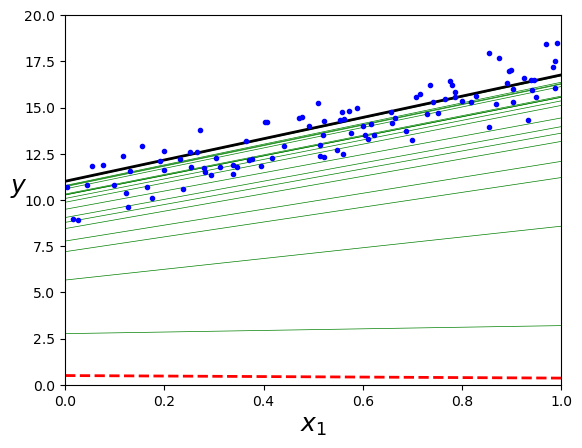

In [48]:
theta_path_sgd=[]
m=len(x_b)
np.random.seed(42)
n_epochs=50

t0,t1 = 5, 50

def learnig_schedule(t):
    return t0/(t+t1)

theta=np.random.randn(2,1)

for epoch in range(n_epochs):
    for i in range(m):
        if epoch==0 and i<20:
            y_predict=x_new_b.dot(theta)
            if i>=19:
                color="black"
                stile="-"
                linewidth=2
            elif i>0:
                color="green"
                style="-"
                linewidth=0.5
            
            else:
                color="red"
                style="--"
                linewidth=2
                
            plt.plot(x_new, y_predict, linestyle=style, color=color, linewidth=linewidth)
        random_index=np.random.randint(m)
        xi=x_b[random_index:random_index+1]
        yi=y[random_index:random_index+1]
        gradients=2*xi.T.dot(xi.dot(theta)-yi)
        eta=learnig_schedule(epoch*m+i)
        theta=theta-eta*gradients
        theta_path_sgd.append(theta)

plt.plot(x, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 1, 0, 20])
plt.show()            

In [49]:
print("Найден вектор параметр ЛР: \n", theta)

print("Значение прогноза линейной регрессии: \n", y_predict)
rmse_lr=np.sqrt(mean_squared_error(y_target, y_predict))
r2_lr=r2_score(y_target, y_predict)
print("RMSE fr LR:", rmse_lr)
print("R2_score for LR:", r2_lr)


Найден вектор параметр ЛР: 
 [[10.24952109]
 [ 6.64330287]]
Значение прогноза линейной регрессии: 
 [[11.00865165]
 [16.76435657]]
RMSE fr LR: 0.7324295100339199
R2_score for LR: 0.9562079194148141


In [50]:
from sklearn.linear_model import SGDRegressor

sgd_reg=SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1, random_state=42)
lin_regSGD=sgd_reg.fit(x,y.ravel())
y_predict=lin_regSGD.predict(x_new)
y_target=4+3*x_new
print("Найденный вектор параметров ЛР:\n", theta)

print("Значение прогноза линейной регрессии: \n", y_predict)

Найденный вектор параметров ЛР:
 [[10.24952109]
 [ 6.64330287]]
Значение прогноза линейной регрессии: 
 [10.23009976 16.8228468 ]


Найденный вектор параметров ЛР:
 [[10.13378111]
 [ 6.72269139]]
Значение прогноза линейной регрессии: 
 [[10.13378111]
 [16.8564725 ]]


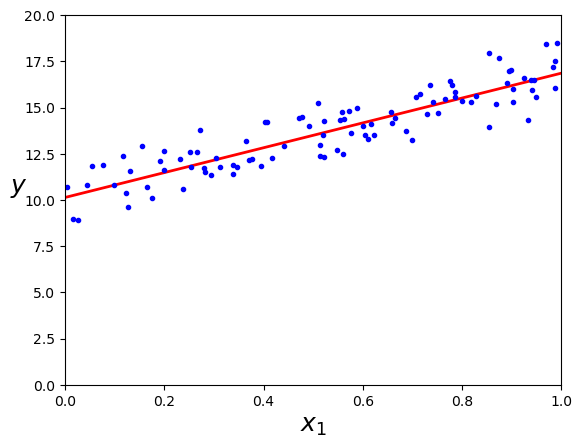

In [51]:
theta_path_mgd=[]
n_interations=50
minibatch_size=20

np.random.seed(42)

theta=np.random.randn(2,1)
t0,t1=200, 1000
def learning_schedule(t):
    return t0/(t+t1)

t=0
for epoch in range(n_interations):
    shuffled_indices=np.random.permutation(m)
    x_b_shuffled=x_b[shuffled_indices]
    y_shuffled=y[shuffled_indices]
    for i in range(0, m, minibatch_size):           
        t+=1
        xi=x_b_shuffled[i:i+minibatch_size]
        yi=y_shuffled[i:i+minibatch_size]
        gradients=2/minibatch_size*xi.T.dot(xi.dot(theta)-yi)
        eta=learning_schedule(t)
        theta=theta-eta*gradients
        theta_path_mgd.append(theta)



y_predict=x_new_b.dot(theta)
y_target=4+3*x_new
print("Найденный вектор параметров ЛР:\n", theta)
print("Значение прогноза линейной регрессии: \n", y_predict)

x_line = np.linspace(0, 1, 100).reshape(100, 1)
x_line_b = np.c_[np.ones((100, 1)), x_line]

y_line = x_line_b.dot(theta)

plt.plot(x_line, y_line, "r-", linewidth=2)

plt.plot(x, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 1, 0, 20])
plt.show()           

In [54]:
def split_train_test(data, test_ratio):
    shuffled_indices=np.random.permutation(len(data))
    test_set_size=int(len(data)*test_ratio)
    test_indices=shuffled_indices[:test_set_size]
    train_indices=shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

train_set_1, test_set_1=split_train_test(housing, 0.2)


# train_set_1

test_set_1

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
14857,-122.61,38.09,18.0,6205.0,821.0,2311.0,756.0,6.9081,368700.0,<1H OCEAN
937,-121.79,37.31,22.0,2199.0,361.0,1270.0,386.0,5.1149,235700.0,<1H OCEAN
17958,-118.17,34.10,25.0,4444.0,647.0,1922.0,652.0,8.0580,477300.0,<1H OCEAN
14253,-121.48,38.56,46.0,1476.0,344.0,688.0,353.0,2.7316,134700.0,INLAND
5662,-118.31,33.99,44.0,1703.0,358.0,789.0,249.0,1.7083,100000.0,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
13980,-118.37,33.87,23.0,1829.0,331.0,891.0,356.0,6.5755,359900.0,<1H OCEAN
2760,-118.25,33.98,39.0,1553.0,461.0,2271.0,437.0,1.7378,121900.0,<1H OCEAN
14972,-119.75,34.43,23.0,2982.0,837.0,1317.0,787.0,3.3776,283200.0,NEAR OCEAN
19340,-118.22,34.63,4.0,14348.0,2145.0,5839.0,1806.0,5.3799,222400.0,INLAND


In [57]:
from zlib import crc32

def test_set_check(indentifier, test_ratio):
    return crc32(np.int64(indentifier)) & 0xffffffff<test_ratio*2**32

def split_train_test_by_id(data, test_ratio, id_column):
    ids=data[id_column]
    in_test_set=ids.apply(lambda id_: test_set_check(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

housing_with_id=housing.reset_index()
train_set_2, test_set_2=split_train_test_by_id(housing_with_id,0.2,"index")

# train_set_2
test_set_2

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
5,5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
12,12,-122.26,37.85,52.0,2491.0,474.0,1098.0,468.0,3.0750,213500.0,NEAR BAY
16,16,-122.27,37.85,52.0,1966.0,347.0,793.0,331.0,2.7750,152500.0,NEAR BAY
23,23,-122.27,37.84,52.0,1688.0,337.0,853.0,325.0,2.1806,99700.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...,...
20615,20615,-121.54,39.08,23.0,1076.0,216.0,724.0,197.0,2.3598,57500.0,INLAND
20617,20617,-121.53,39.06,20.0,561.0,109.0,308.0,114.0,3.3021,70800.0,INLAND
20622,20622,-121.44,39.00,20.0,755.0,147.0,457.0,157.0,2.4167,67000.0,INLAND
20626,20626,-121.43,39.18,36.0,1124.0,184.0,504.0,171.0,2.1667,93800.0,INLAND


In [58]:
from sklearn.model_selection import train_test_split
train_set, train_set=train_test_split(housing, test_size=0.2, random_state=42)
train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20046,-122.38,40.67,10.0,2281.0,444.0,1274.0,438.0,2.2120,65600.0,INLAND
3024,-118.37,33.83,35.0,1207.0,207.0,601.0,213.0,4.7308,353400.0,<1H OCEAN
15663,-117.24,32.72,39.0,3089.0,431.0,1175.0,432.0,7.5925,466700.0,NEAR OCEAN
20484,-118.44,34.05,18.0,4780.0,1192.0,1886.0,1036.0,4.4674,500001.0,<1H OCEAN
9814,-118.44,34.18,33.0,2127.0,414.0,1056.0,391.0,4.3750,286100.0,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
15362,-121.92,40.52,13.0,4581.0,881.0,1799.0,734.0,2.2993,99500.0,INLAND
16623,-122.08,37.68,26.0,2607.0,682.0,1401.0,607.0,2.6563,184100.0,NEAR BAY
18086,-119.00,35.39,42.0,2839.0,516.0,1203.0,487.0,3.7708,79400.0,INLAND
2144,-117.92,33.63,39.0,1469.0,226.0,553.0,225.0,7.8496,490800.0,<1H OCEAN


Перекрестная валидация-проверка по K блокам

In [59]:
validation_size=0.2
seed=7
x=2-3*np.random.normal(0,1,20)
y=x-2*(x**2)+0.5*(x**3)+np.exp(-x)+np.random.normal(-3,3,20)
x=x[:, np.newaxis]
y=y[:, np.newaxis]

x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=validation_size, random_state=seed)

x_train

array([[ 6.84072476],
       [ 1.0522442 ],
       [ 3.9253281 ],
       [ 1.12431381],
       [ 0.94437805],
       [ 5.54262246],
       [ 2.17688696],
       [-2.4888103 ],
       [ 4.99416654],
       [ 0.68672939],
       [ 2.15468142],
       [ 1.12349202],
       [-1.23630927],
       [ 1.61247805],
       [-1.53282466],
       [ 2.06396922]])

In [60]:
y_train

array([[ 70.3640153 ],
       [ -2.86428805],
       [  3.88289668],
       [ -3.42958751],
       [ -5.01698776],
       [ 28.28394157],
       [ -4.15192808],
       [ -9.76239271],
       [ 11.27909183],
       [ -7.97697773],
       [  1.00609182],
       [ -6.6687818 ],
       [  1.94124689],
       [ -5.56100796],
       [ -8.92093921],
       [-12.92933526]])

In [61]:
x_test

array([[ 3.84231744],
       [-2.41660799],
       [ 1.83505924],
       [ 5.64888254]])

In [62]:
y_test

array([[ -0.89189973],
       [-17.78094783],
       [ -4.92291152],
       [ 31.76298313]])

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
model=LinearRegression()
model.fit(x_train, y_train)
y_pred=model.predict(x_train)
rmse_lin=np.sqrt(mean_squared_error(y_train, y_pred))
r2_lin=r2_score(y_train, y_pred)
print("RMSE for LR: ", rmse_lin)
print("R2 score for LR: ", r2_lin)

RMSE for LR:  13.004265678011684
R2 score for LR:  0.5697350552374832


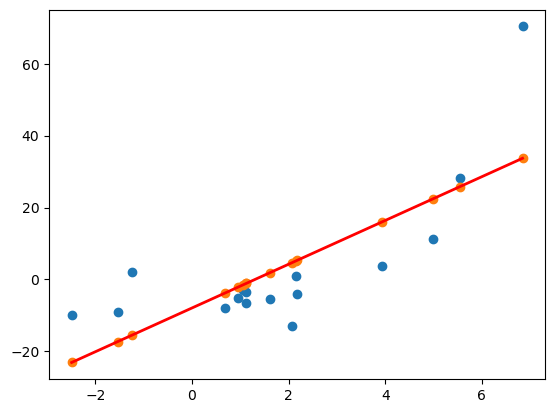

In [66]:
import pandas as pd
x=x_train.reshape(x_train.shape[0])

y=y_pred.reshape(y_pred.shape[0])
xy=pd.DataFrame({'x': x, 'y': y})
xy_sort=xy.sort_values(by='x')

import matplotlib.pyplot as plt

plt.plot(x_train, y_train, "o")
plt.plot(x_train, y_pred, 'o')
plt.plot(xy_sort.x, xy_sort.y, 'r-', linewidth=2)
plt.show()

In [68]:
polynomial_features=PolynomialFeatures(degree=2)
x_poly=polynomial_features.fit_transform(x_train)
model=LinearRegression()
model.fit(x_poly, y_train)
y_poly_pred=model.predict(x_poly)
rmse=np.sqrt(mean_squared_error(y_train, y_poly_pred))
r2_poly=r2_score(y_train, y_poly_pred)
print("RMSE for Polynomial Regression: ", rmse)
print("R2 score for Linear Regerssion: ", r2_poly)

x_poly

RMSE for Polynomial Regression:  7.199723733440413
R2 score for Linear Regerssion:  0.8681148307593786


array([[ 1.        ,  6.84072476, 46.79551526],
       [ 1.        ,  1.0522442 ,  1.10721786],
       [ 1.        ,  3.9253281 , 15.40820068],
       [ 1.        ,  1.12431381,  1.26408154],
       [ 1.        ,  0.94437805,  0.89184991],
       [ 1.        ,  5.54262246, 30.72066375],
       [ 1.        ,  2.17688696,  4.73883685],
       [ 1.        , -2.4888103 ,  6.19417672],
       [ 1.        ,  4.99416654, 24.94169946],
       [ 1.        ,  0.68672939,  0.47159725],
       [ 1.        ,  2.15468142,  4.64265202],
       [ 1.        ,  1.12349202,  1.26223432],
       [ 1.        , -1.23630927,  1.52846061],
       [ 1.        ,  1.61247805,  2.60008546],
       [ 1.        , -1.53282466,  2.34955143],
       [ 1.        ,  2.06396922,  4.25996896]])

In [ ]:
x=x_train.reshape(x_train.shape[0])
y=y_poly_pred.reshape(y_pred.shape[0])
xy=pd.DataFrame({'x': x, 'y': y})
xy_sort=xy.sort_values(by='x')

plt.plot(x_train, y_train, 'o')
plt.plot(x_train, y_poly_pred, 'o')
plt.plot(xy_sort.x, xy_sort.y, 'r-', linewidth=2)
plt.show()